# M2 EDA Dashboard: Housing Prices + Mortgage Rates

In [1]:
# Section 1: Imports + Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import sys

# ensure config module import works
sys.path.append(str(Path.cwd() / 'code'))
from config_paths import FIGURES_DIR, FINAL_DATA_DIR, REPORTS_DIR

# load data
panel = pd.read_csv(FINAL_DATA_DIR / 'metro_mortgage_panel.csv', parse_dates=['date'])

print('data rows', panel.shape[0])
print(panel.head())


✓ Project structure verified at: /workspaces/qm2023-capstone-kenzie-reese-and-carter
data rows 77673
   RegionID    RegionName StateName       date  SizeRank RegionType  \
0    394297  Aberdeen, SD        SD 2009-03-31       677        msa   
1    394297  Aberdeen, SD        SD 2009-06-30       677        msa   
2    394297  Aberdeen, SD        SD 2009-09-30       677        msa   
3    394297  Aberdeen, SD        SD 2009-12-31       677        msa   
4    394297  Aberdeen, SD        SD 2010-03-31       677        msa   

     price_index  MORTGAGE30US  
0  125079.142534      5.060000  
1  124593.031335      5.012308  
2  124040.448081      5.162308  
3  123924.336564      4.922143  
4  123965.143897      4.995833  


## Section 2: Data preparation and summary statistics

In [2]:
# create outcome variable: quarterly price growth for each metro
panel = panel.sort_values(['RegionID', 'date'])
panel['price_index_growth'] = panel.groupby('RegionID')['price_index'].pct_change() * 100
panel['log_price'] = np.log(panel['price_index'])

# a small filter for valid growth and rates
panel_clean = panel.dropna(subset=['price_index_growth', 'MORTGAGE30US'])
print('rows after clean', panel_clean.shape[0])
print(panel_clean[['price_index_growth','MORTGAGE30US','SizeRank']].describe())


rows after clean 76779
       price_index_growth  MORTGAGE30US      SizeRank
count        76779.000000  76779.000000  76779.000000
mean             0.961674      4.989125    432.311739
std              1.954087      1.343164    267.279178
min            -21.347670      2.760714      1.000000
25%             -0.047262      3.842308    195.000000
50%              0.907182      4.650769    418.000000
75%              1.870464      6.226429    657.000000
max             22.822407      8.316154    939.000000


## Section 3: Correlation analysis

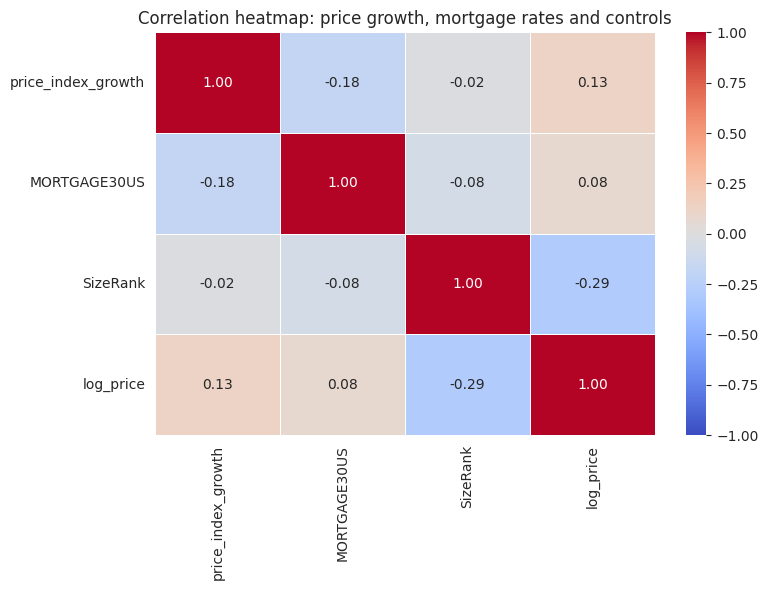

Caption: The heatmap reveals ...


In [3]:
vars_to_plot = ['price_index_growth', 'MORTGAGE30US', 'SizeRank', 'log_price']
corr_matrix = panel_clean[vars_to_plot].corr()

plt.figure(figsize=(8,6))
sns.set_style('whitegrid')
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=.5)
ax.set_title('Correlation heatmap: price growth, mortgage rates and controls')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot1_correlation_heatmap.png', dpi=300)
plt.show()

print('Caption: The heatmap reveals ...')


## Section 4: Time series of outcome variable

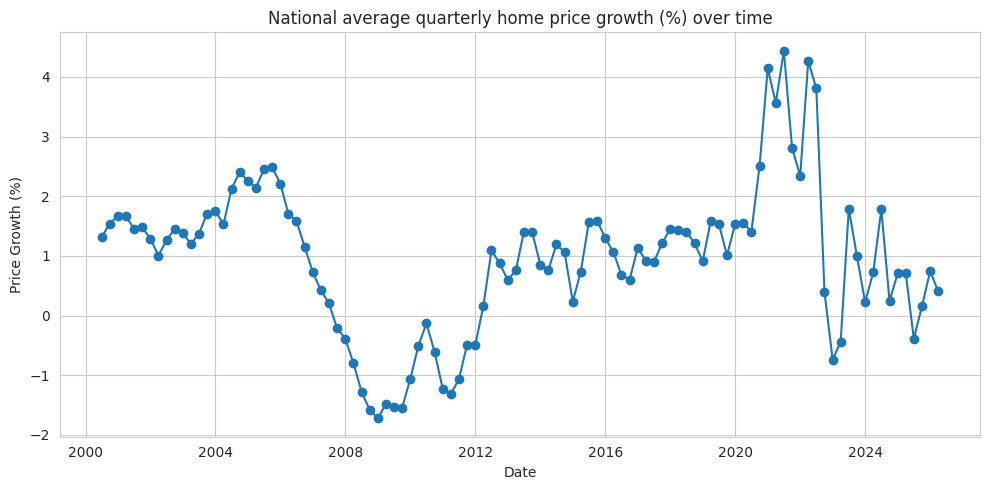

In [4]:
# national quarterly average growth
national = panel_clean.groupby('date').agg({'price_index':'mean', 'price_index_growth':'mean', 'MORTGAGE30US':'mean'}).reset_index()

plt.figure(figsize=(10,5))
plt.plot(national['date'], national['price_index_growth'], marker='o', linestyle='-')
plt.title('National average quarterly home price growth (%) over time')
plt.xlabel('Date')
plt.ylabel('Price Growth (%)')
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot2_outcome_time_series.png', dpi=300)
plt.show()


## Section 5: Dual-axis plot (outcome vs driver)

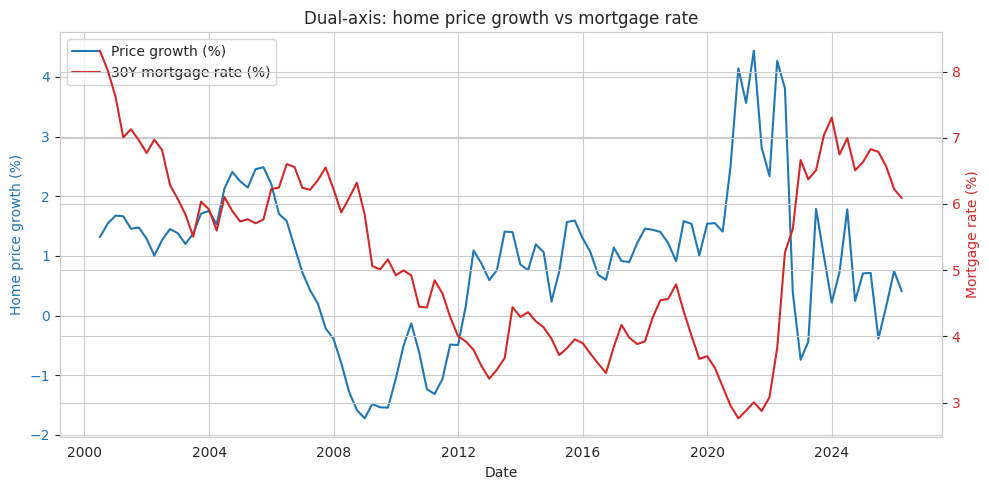

In [5]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.plot(national['date'], national['price_index_growth'], color='tab:blue', label='Price growth (%)')
ax2.plot(national['date'], national['MORTGAGE30US'], color='tab:red', label='30Y mortgage rate (%)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Home price growth (%)', color='tab:blue')
ax2.set_ylabel('Mortgage rate (%)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('Dual-axis: home price growth vs mortgage rate')
lines, labels = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels();
ax1.legend(lines+lines2, labels+labels2, loc='upper left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'plot3_dual_axis.png', dpi=300)
plt.show()


## Section 6: Lagged effect analysis

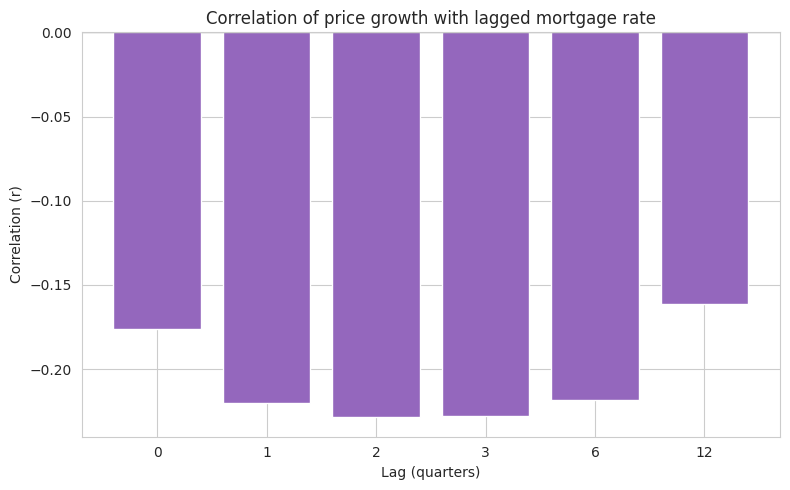

lag correlations [(0, np.float64(-0.17587317868217198)), (1, np.float64(-0.2200474231729863)), (2, np.float64(-0.22870017438699233)), (3, np.float64(-0.22757728233041283)), (6, np.float64(-0.21860319008715048)), (12, np.float64(-0.16136931804493354))]


In [6]:
lags = [0,1,2,3,6,12]
lag_corr = []
for lag in lags:
    panel_clean[f'mortgage_lag_{lag}'] = panel_clean.groupby('RegionID')['MORTGAGE30US'].shift(lag)
    df = panel_clean.dropna(subset=[f'mortgage_lag_{lag}', 'price_index_growth'])
    lag_corr.append(df['price_index_growth'].corr(df[f'mortgage_lag_{lag}']))

plt.figure(figsize=(8,5))
plt.bar([str(l) for l in lags], lag_corr, color='tab:purple')
plt.title('Correlation of price growth with lagged mortgage rate')
plt.xlabel('Lag (quarters)')
plt.ylabel('Correlation (r)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot4_lagged_correlation.png', dpi=300)
plt.show()
print('lag correlations', list(zip(lags, lag_corr)))


## Section 7: Group Analysis (State-level)

/tmp/ipykernel_14713/2928133586.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='StateName', y='price_index_growth', palette='colorblind')


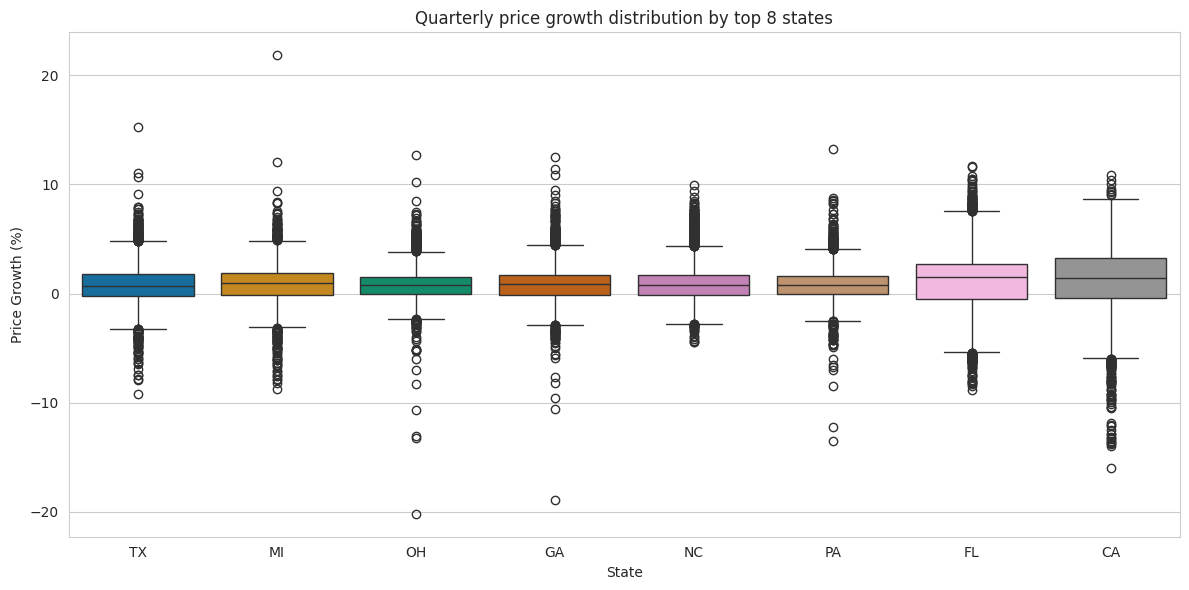

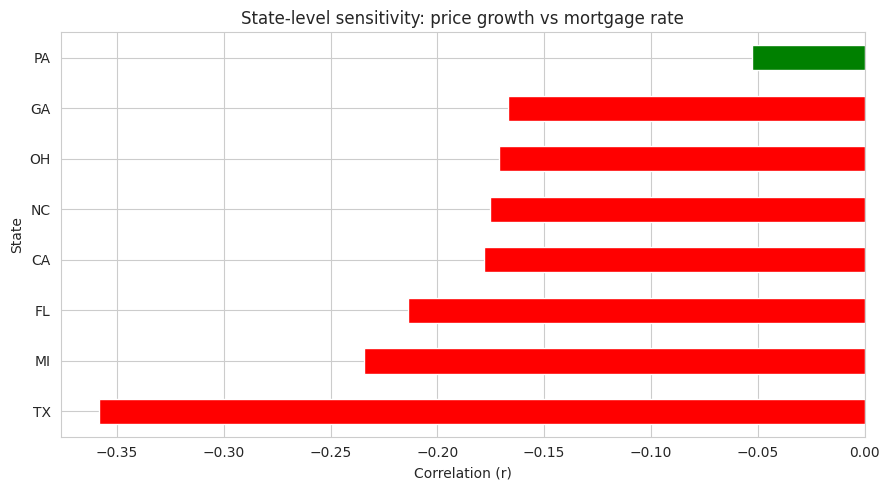

StateName
TX   -0.358467
MI   -0.234361
FL   -0.213572
CA   -0.177993
NC   -0.175540
OH   -0.171179
GA   -0.167167
PA   -0.052835
dtype: float64


In [7]:
top_states = panel_clean['StateName'].value_counts().nlargest(8).index.tolist()
sub = panel_clean[panel_clean['StateName'].isin(top_states)]

plt.figure(figsize=(12,6))
sns.boxplot(data=sub, x='StateName', y='price_index_growth', palette='colorblind')
plt.title('Quarterly price growth distribution by top 8 states')
plt.xlabel('State')
plt.ylabel('Price Growth (%)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot5_group_boxplot.png', dpi=300)
plt.show()

state_sensitivity = sub.groupby('StateName').apply(lambda g: g['price_index_growth'].corr(g['MORTGAGE30US']))
state_sensitivity = state_sensitivity.sort_values()

plt.figure(figsize=(9,5))
colors = ['red' if v < -0.15 else 'green' for v in state_sensitivity]
state_sensitivity.plot(kind='barh', color=colors)
plt.title('State-level sensitivity: price growth vs mortgage rate')
plt.xlabel('Correlation (r)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot6_group_sensitivity.png', dpi=300)
plt.show()
print(state_sensitivity)


## Section 8: Factor/control relationships (scatter plots)

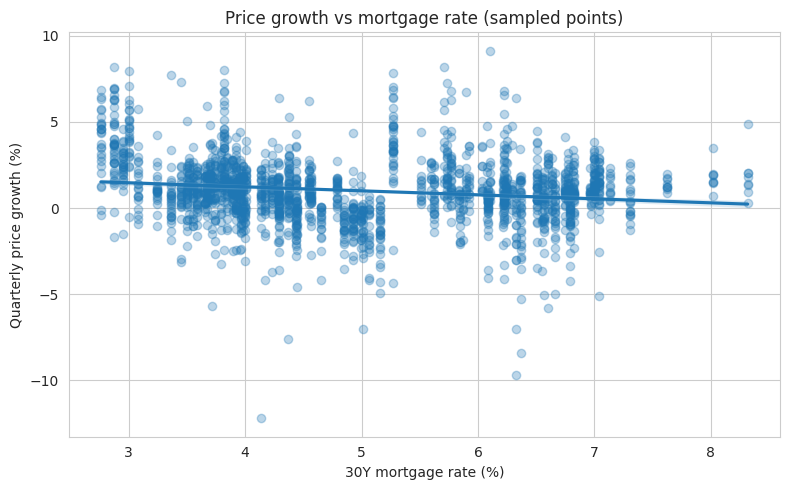

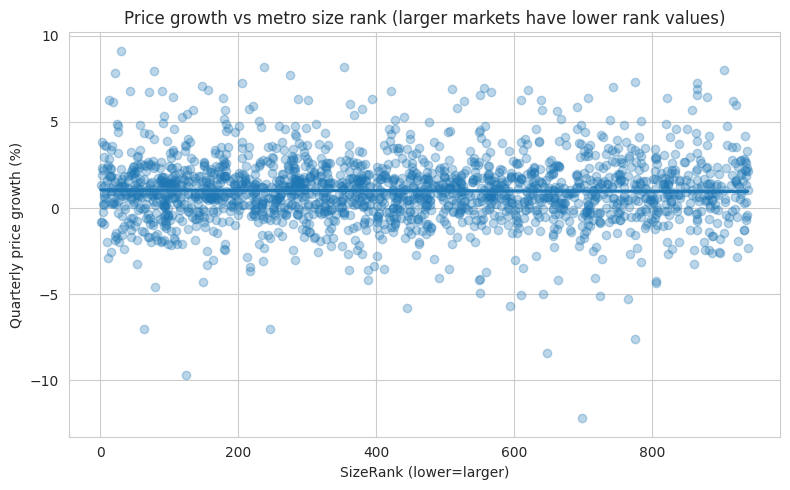

In [8]:
plt.figure(figsize=(8,5))
sns.regplot(data=panel_clean.sample(2000, random_state=42), x='MORTGAGE30US', y='price_index_growth', scatter_kws={'alpha':0.3})
plt.title('Price growth vs mortgage rate (sampled points)')
plt.xlabel('30Y mortgage rate (%)')
plt.ylabel('Quarterly price growth (%)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot7_scatter_driver.png', dpi=300)
plt.show()

plt.figure(figsize=(8,5))
sns.regplot(data=panel_clean.sample(2000, random_state=42), x='SizeRank', y='price_index_growth', scatter_kws={'alpha':0.3})
plt.title('Price growth vs metro size rank (larger markets have lower rank values)')
plt.xlabel('SizeRank (lower=larger)')
plt.ylabel('Quarterly price growth (%)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot7b_scatter_control.png', dpi=300)
plt.show()


## Section 9: Time series decomposition

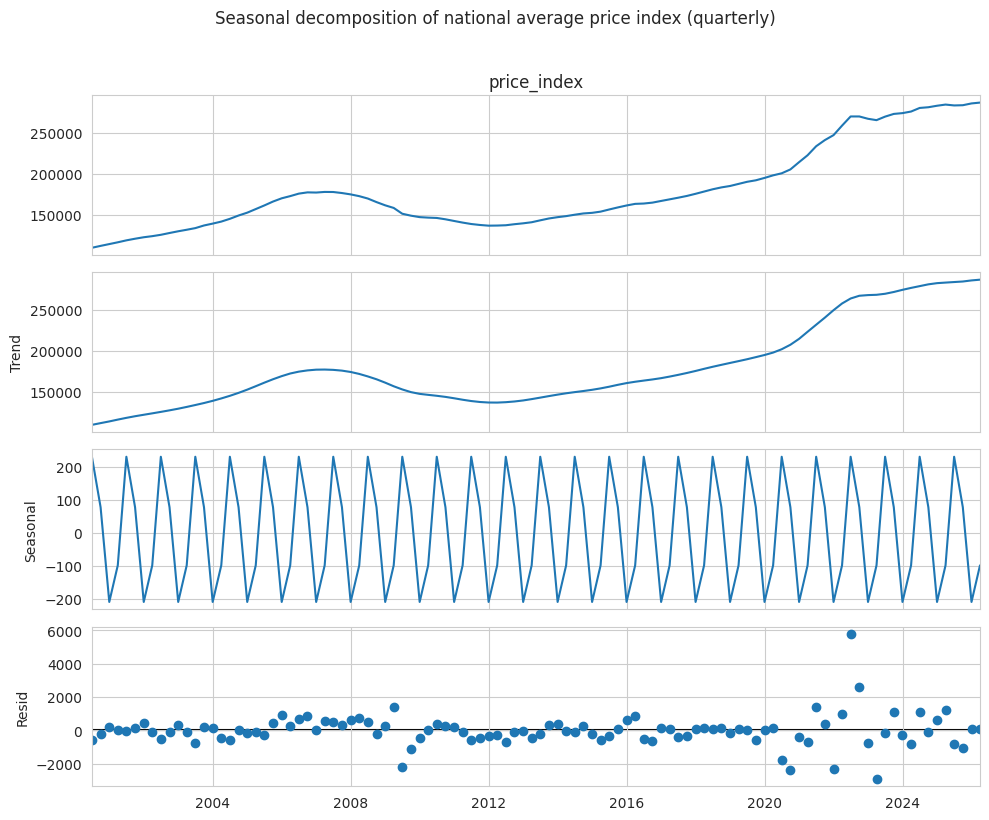

In [9]:
national_ts = national.set_index('date')['price_index'].asfreq('QE')
result = seasonal_decompose(national_ts, model='additive', period=4, extrapolate_trend='freq')

fig = result.plot()
fig.set_size_inches(10,8)
plt.suptitle('Seasonal decomposition of national average price index (quarterly)', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot8_seasonal_decompose.png', dpi=300)
plt.show()


## Notebook completed: plot files saved to `results/figures` and analysis is ready.